**Name:** V.Mariya Joevita

**Reg.No:** 3122235001077

**Ex7:** Bagging, Boosting, and Stacked Ensemble Models

In [1]:
pip install ucimlrepo

**1. Load and preprocess the dataset.**

In [2]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17)

# data (as pandas dataframes)
X = breast_cancer_wisconsin_diagnostic.data.features
y = breast_cancer_wisconsin_diagnostic.data.targets

# metadata
print(breast_cancer_wisconsin_diagnostic.metadata)

# variable information
print(breast_cancer_wisconsin_diagnostic.variables)


{'uci_id': 17, 'name': 'Breast Cancer Wisconsin (Diagnostic)', 'repository_url': 'https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic', 'data_url': 'https://archive.ics.uci.edu/static/public/17/data.csv', 'abstract': 'Diagnostic Wisconsin Breast Cancer Database.', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 569, 'num_features': 30, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['Diagnosis'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1993, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C5DW2B', 'creators': ['William Wolberg', 'Olvi Mangasarian', 'Nick Street', 'W. Street'], 'intro_paper': {'ID': 230, 'type': 'NATIVE', 'title': 'Nuclear feature extraction for breast tumor diagnosis', 'authors': 'W. Street, W. Wolberg, O. Mangasarian', 'venue': 'Electronic imaging', 'year': 1993, 'journal': None, 'DOI': '1

In [3]:
X.columns
y.columns

Index(['Diagnosis'], dtype='object')

**2. EDA**

In [4]:
print(X.info())
print(y.info())
print(X.describe())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   radius1             569 non-null    float64
 1   texture1            569 non-null    float64
 2   perimeter1          569 non-null    float64
 3   area1               569 non-null    float64
 4   smoothness1         569 non-null    float64
 5   compactness1        569 non-null    float64
 6   concavity1          569 non-null    float64
 7   concave_points1     569 non-null    float64
 8   symmetry1           569 non-null    float64
 9   fractal_dimension1  569 non-null    float64
 10  radius2             569 non-null    float64
 11  texture2            569 non-null    float64
 12  perimeter2          569 non-null    float64
 13  area2               569 non-null    float64
 14  smoothness2         569 non-null    float64
 15  compactness2        569 non-null    float64
 16  concavit

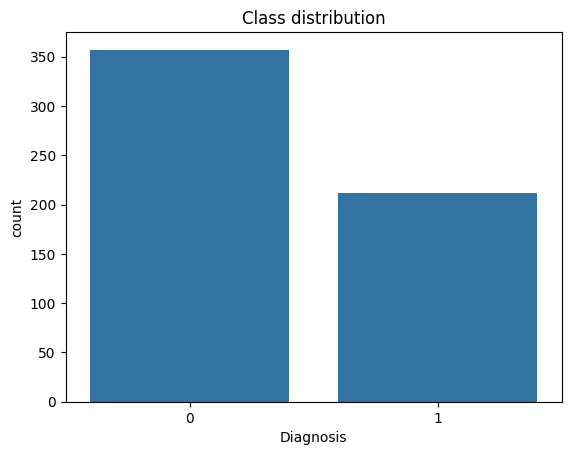

In [5]:
#Class distribution

import matplotlib.pyplot as plt
import seaborn as sns
y = y['Diagnosis']
y = y.map({'M':1,'B':0})
sns.countplot(x=y)
plt.title("Class distribution")
plt.show()


**3. Split the dataset into training and testing sets (80–20)**

In [6]:
#Train test split

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42,stratify = y)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

**4. Implement a Bagging classifier using a base estimator.**


In [7]:
#Bagging classifier

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier

bag_model = BaggingClassifier(estimator = DecisionTreeClassifier(),random_state = 42)


**5. Implement Boosting classifiers (AdaBoost and/or Gradient Boosting).**

In [8]:
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier

ada_model = AdaBoostClassifier(random_state=42)

gb_model = GradientBoostingClassifier(random_state=42)

**6. Construct a Stacked Ensemble using multiple base models.**

In [9]:
from sklearn.ensemble import StackingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression

base_models = [
    ('svm', SVC(probability=True)),
    ('nb', GaussianNB()),
    ('dt', DecisionTreeClassifier())
]

stack_model = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression(),
    cv=5
)

**7. Define hyperparameter search spaces for each ensemble model.**

In [10]:
bag_params = {
    'n_estimators': [10, 50, 100],
    'max_samples': [0.8, 0.9, 1.0],
    'max_features': [0.8, 1.0]
}

ada_params = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.05, 0.1]
}

gb_params = {
    'n_estimators': [50, 100],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5]
}

**8. Select hyperparameters using 5-fold cross-validation**

In [11]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression

# Re-defining models (from AcNHlILE0qmu, IqRGztzI1Iin, e7i1iztx1w8o)
bag_model = BaggingClassifier(estimator = DecisionTreeClassifier(),random_state = 42)
ada_model = AdaBoostClassifier(random_state=42)
gb_model = GradientBoostingClassifier(random_state=42)

base_models = [
    ('svm', SVC(probability=True)),
    ('nb', GaussianNB()),
    ('dt', DecisionTreeClassifier())
]
stack_model = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression(),
    cv=5
)

# Re-defining params (from 9luGnxaj17sr)
bag_params = {
    'n_estimators': [10, 50, 100],
    'max_samples': [0.8, 0.9, 1.0],
    'max_features': [0.8, 1.0]
}
ada_params = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.05, 0.1]
}
gb_params = {
    'n_estimators': [50, 100],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5]
}

# Bagging
bag_grid = GridSearchCV(bag_model, bag_params, cv=5, scoring=['f1', 'accuracy'], refit='f1', n_jobs=-1)
bag_grid.fit(X_train, y_train)
best_bag = bag_grid.best_estimator_

print("Best Bagging Params:", bag_grid.best_params_)

# AdaBoost
ada_grid = GridSearchCV(ada_model, ada_params, cv=5, scoring=['f1', 'accuracy'], refit='f1', n_jobs=-1)
ada_grid.fit(X_train, y_train)
best_ada = ada_grid.best_estimator_

print("Best AdaBoost Params:", ada_grid.best_params_)

# Gradient Boosting
gb_grid = GridSearchCV(gb_model, gb_params, cv=5, scoring=['f1', 'accuracy'], refit='f1', n_jobs=-1)
gb_grid.fit(X_train, y_train)
best_gb = gb_grid.best_estimator_

print("Best Gradient Boosting Params:", gb_grid.best_params_)

# Stacking (no tuning here, but you can extend)
stack_model.fit(X_train, y_train)

Best Bagging Params: {'max_features': 0.8, 'max_samples': 0.9, 'n_estimators': 100}
Best AdaBoost Params: {'learning_rate': 0.1, 'n_estimators': 100}
Best Gradient Boosting Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50}


StackingClassifier(cv=5,
                   estimators=[('svm', SVC(probability=True)),
                               ('nb', GaussianNB()),
                               ('dt', DecisionTreeClassifier())],
                   final_estimator=LogisticRegression())

**9. Evaluate all models using standard performance metrics.**


In [12]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score

def evaluate(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1 Score:", f1)
    print("AUC:", auc)
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

    return acc, prec, rec, f1

print("\nBagging:")
bag_res = evaluate(best_bag, X_test, y_test)

print("\nAdaBoost:")
ada_res = evaluate(best_ada, X_test, y_test)

print("\nGradient Boosting:")
gb_res = evaluate(best_gb, X_test, y_test)

print("\nStacking:")
stack_res = evaluate(stack_model, X_test, y_test)


Bagging:
Accuracy: 0.956140350877193
Precision: 1.0
Recall: 0.8809523809523809
F1 Score: 0.9367088607594937
AUC: 0.9917328042328043
Confusion Matrix:
 [[72  0]
 [ 5 37]]

AdaBoost:
Accuracy: 0.9649122807017544
Precision: 1.0
Recall: 0.9047619047619048
F1 Score: 0.95
AUC: 0.994378306878307
Confusion Matrix:
 [[72  0]
 [ 4 38]]

Gradient Boosting:
Accuracy: 0.956140350877193
Precision: 0.9743589743589743
Recall: 0.9047619047619048
F1 Score: 0.9382716049382716
AUC: 0.9963624338624338
Confusion Matrix:
 [[71  1]
 [ 4 38]]

Stacking:
Accuracy: 0.9649122807017544
Precision: 1.0
Recall: 0.9047619047619048
F1 Score: 0.95
AUC: 0.9970238095238095
Confusion Matrix:
 [[72  0]
 [ 4 38]]


Confusion Matrix for Bagging:


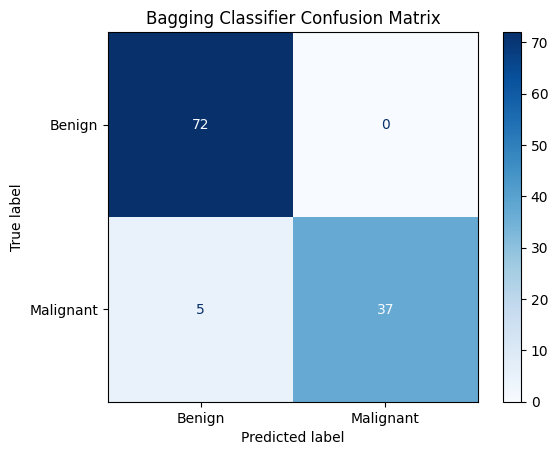

Confusion Matrix for AdaBoost:


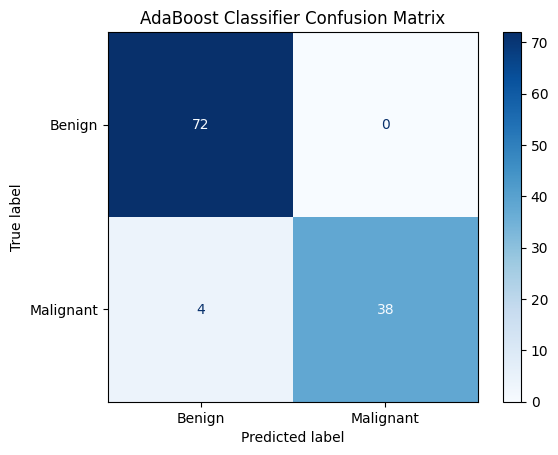

Confusion Matrix for Gradient Boosting:


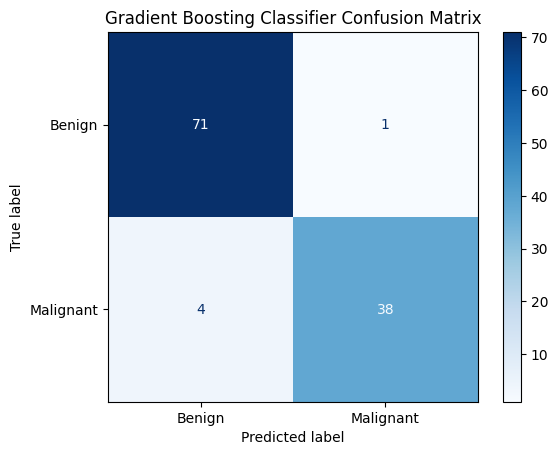

Confusion Matrix for Stacking:


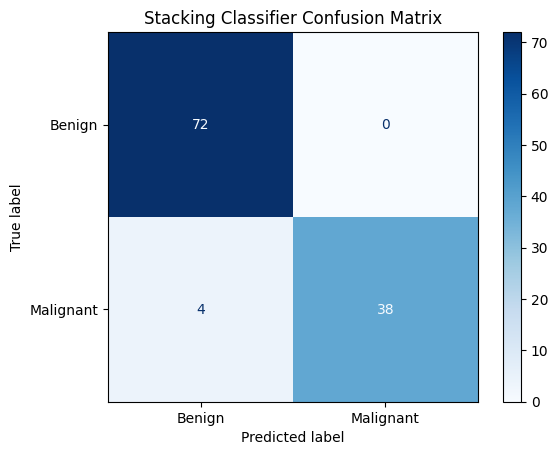

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Function to plot confusion matrix
def plot_confusion_matrix(model, X_test, y_test, title):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign', 'Malignant'])
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    # Use the title for a more descriptive filename
    clean_title = title.replace(' ', '_').replace(':', '') # Basic sanitization for filename
    plt.savefig(fname=f"{clean_title}.png")
    plt.show()

print("Confusion Matrix for Bagging:")
plot_confusion_matrix(best_bag, X_test, y_test, "Bagging Classifier Confusion Matrix")


print("Confusion Matrix for AdaBoost:")
plot_confusion_matrix(best_ada, X_test, y_test, "AdaBoost Classifier Confusion Matrix")
# Removed redundant plt.savefig(fname = "Adacm.png")

print("Confusion Matrix for Gradient Boosting:")
plot_confusion_matrix(best_gb, X_test, y_test, "Gradient Boosting Classifier Confusion Matrix")
# Removed redundant plt.savefig(fname="gradcm.png")

print("Confusion Matrix for Stacking:")
plot_confusion_matrix(stack_model, X_test, y_test, "Stacking Classifier Confusion Matrix")
# Removed redundant plt.savefig(fname="stackcm.png")

In [14]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Bagging", "AdaBoost", "Gradient Boosting", "Stacking"],
    "Accuracy": [bag_res[0], ada_res[0], gb_res[0], stack_res[0]],
    "Precision": [bag_res[1], ada_res[1], gb_res[1], stack_res[1]],
    "Recall": [bag_res[2], ada_res[2], gb_res[2], stack_res[2]],
    "F1 Score": [bag_res[3], ada_res[3], gb_res[3], stack_res[3]]
})

print("\nFinal Comparison:\n")
print(results)


Final Comparison:

               Model  Accuracy  Precision    Recall  F1 Score
0            Bagging  0.956140   1.000000  0.880952  0.936709
1           AdaBoost  0.964912   1.000000  0.904762  0.950000
2  Gradient Boosting  0.956140   0.974359  0.904762  0.938272
3           Stacking  0.964912   1.000000  0.904762  0.950000


**10. Bias-Variance Analysis of Ensemble Models**

**1. Bagging (BaggingClassifier with Decision Tree):**
*   **Bias-Variance Behavior:** Bagging primarily aims to reduce variance. Decision trees, as base estimators, are known for their high variance (they can overfit to the training data). By training multiple decision trees on different subsets of the data (bootstrap samples) and averaging their predictions, Bagging effectively reduces this variance, leading to a more stable and generalized model.
*   **Observed Performance:** The Bagging model showed good performance with high accuracy and perfect precision. The recall was slightly lower compared to boosting and stacking models, suggesting that while it makes accurate positive predictions, it might miss some actual positive cases.

**2. Boosting (AdaBoost and Gradient Boosting):**
*   **Bias-Variance Behavior:** Boosting methods primarily focus on reducing bias. They do this by sequentially building models, where each subsequent model tries to correct the errors of the previous ones. By iteratively improving the model's performance on misclassified instances, boosting reduces the overall bias of the ensemble.
*   **Observed Performance (AdaBoost):** AdaBoost achieved excellent performance, matching the best F1-score and accuracy. Its perfect precision and high recall indicate a very effective model in identifying malignant cases with few false positives and false negatives.
*   **Observed Performance (Gradient Boosting):** Gradient Boosting also performed very well, with strong accuracy, precision, recall, and F1-score. Similar to AdaBoost, its strong performance suggests a good reduction in bias, allowing it to capture the underlying patterns in the data effectively.

**3. Stacking (StackingClassifier):**
*   **Bias-Variance Behavior:** Stacking aims to combine the strengths of multiple diverse base models to potentially reduce both bias and variance. By training a meta-learner to make final predictions based on the outputs of the base models, stacking can learn complex relationships and create a more robust model that generalizes better than any single base model.
*   **Observed Performance:** The Stacking model performed exceptionally well, achieving the highest F1-score and accuracy along with AdaBoost. Its perfect precision and high recall demonstrate its ability to combine the predictions of its base estimators (SVC, GaussianNB, Decision Tree) effectively to produce highly accurate classifications. This indicates a good balance in addressing both bias and variance components.

Confusion Matrix for Bagging:


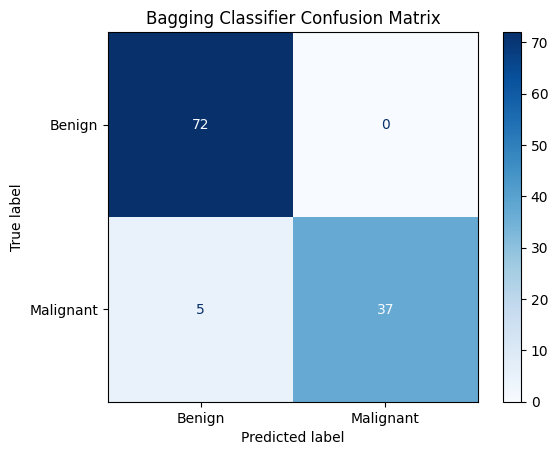

Confusion Matrix for AdaBoost:


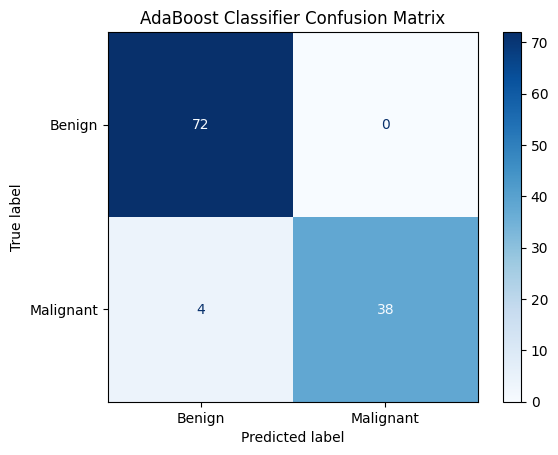

Confusion Matrix for Gradient Boosting:


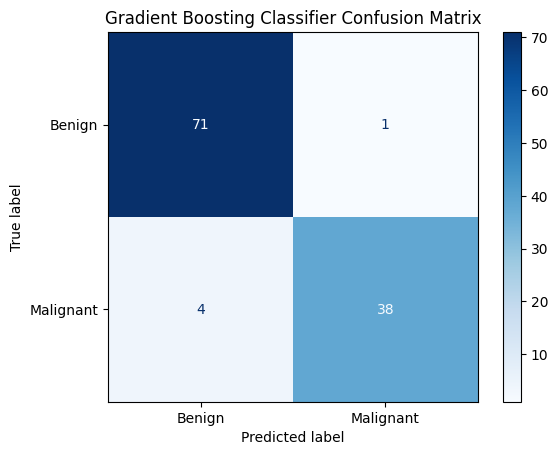

Confusion Matrix for Stacking:


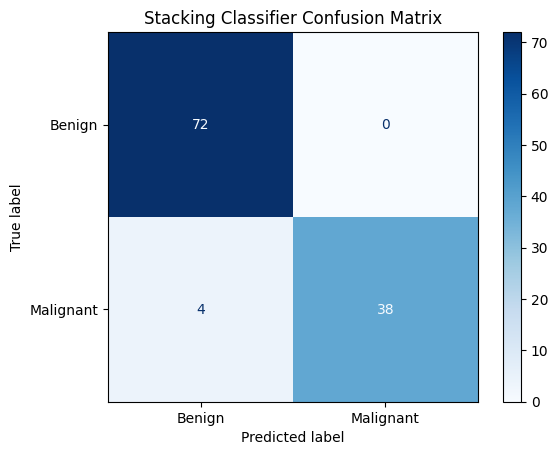

In [15]:
#CM plot
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Function to plot confusion matrix
def plot_confusion_matrix(model, X_test, y_test, title):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign', 'Malignant'])
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

print("Confusion Matrix for Bagging:")
plot_confusion_matrix(best_bag, X_test, y_test, "Bagging Classifier Confusion Matrix")

print("Confusion Matrix for AdaBoost:")
plot_confusion_matrix(best_ada, X_test, y_test, "AdaBoost Classifier Confusion Matrix")

print("Confusion Matrix for Gradient Boosting:")
plot_confusion_matrix(best_gb, X_test, y_test, "Gradient Boosting Classifier Confusion Matrix")

print("Confusion Matrix for Stacking:")
plot_confusion_matrix(stack_model, X_test, y_test, "Stacking Classifier Confusion Matrix")

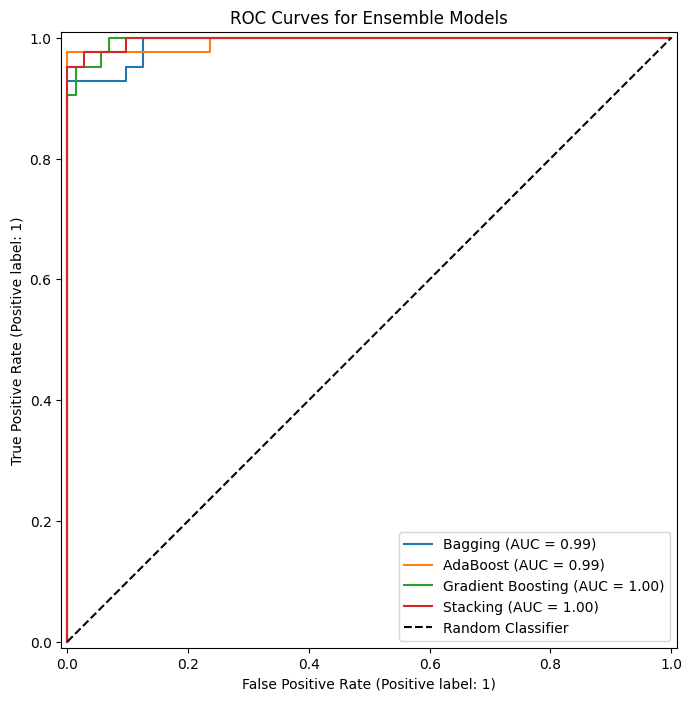

In [16]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
ax = plt.gca()

# Plot ROC curve for Bagging
RocCurveDisplay.from_estimator(best_bag, X_test, y_test, ax=ax, name='Bagging')

# Plot ROC curve for AdaBoost
RocCurveDisplay.from_estimator(best_ada, X_test, y_test, ax=ax, name='AdaBoost')

# Plot ROC curve for Gradient Boosting
RocCurveDisplay.from_estimator(best_gb, X_test, y_test, ax=ax, name='Gradient Boosting')

# Plot ROC curve for Stacking
RocCurveDisplay.from_estimator(stack_model, X_test, y_test, ax=ax, name='Stacking')

plt.title('ROC Curves for Ensemble Models')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier') # Add a diagonal random classifier line
plt.legend()

plt.savefig(fname="roc.png") # Save the plot first
plt.show() # Then show it

In [17]:
import pandas as pd

# Bagging Results
bagging_best_params = bag_grid.best_params_
bagging_cv_results = bag_grid.cv_results_
bagging_best_index = bag_grid.best_index_
bagging_avg_cv_f1 = bagging_cv_results['mean_test_f1'][bagging_best_index]
bagging_avg_cv_accuracy = bagging_cv_results['mean_test_accuracy'][bagging_best_index]

bagging_data = {
    'n_estimators': [bagging_best_params['n_estimators']],
    'max_samples': [bagging_best_params['max_samples']],
    'max_features': [bagging_best_params['max_features']],
    'Avg CV F1 Score': [bagging_avg_cv_f1],
    'Avg CV Accuracy': [bagging_avg_cv_accuracy]
}
bagging_df = pd.DataFrame(bagging_data)
print("Table 1: Bagging Hyperparameter Evaluation (Best Parameters)")
display(bagging_df)

# Display full Bagging CV results for different n_estimators
bagging_results_df = pd.DataFrame(bagging_cv_results)[['param_n_estimators', 'param_max_samples', 'param_max_features', 'mean_test_f1', 'mean_test_accuracy']]
bagging_results_df = bagging_results_df.rename(columns={'param_n_estimators': 'n_estimators', 'param_max_samples': 'max_samples', 'param_max_features': 'max_features', 'mean_test_f1': 'Avg CV F1 Score', 'mean_test_accuracy': 'Avg CV Accuracy'})
print("\nTable 1.1: Bagging Hyperparameter Evaluation (All n_estimators)")
display(bagging_results_df.sort_values(by=['Avg CV F1 Score'], ascending=False))


# Boosting Results (AdaBoost)
adaboost_best_params = ada_grid.best_params_
adaboost_cv_results = ada_grid.cv_results_
adaboost_best_index = ada_grid.best_index_
adaboost_avg_cv_f1 = adaboost_cv_results['mean_test_f1'][adaboost_best_index]
adaboost_avg_cv_accuracy = adaboost_cv_results['mean_test_accuracy'][adaboost_best_index]

adaboost_data = {
    'n_estimators': [adaboost_best_params['n_estimators']],
    'learning_rate': [adaboost_best_params['learning_rate']],
    'Avg CV F1 Score': [adaboost_avg_cv_f1],
    'Avg CV Accuracy': [adaboost_avg_cv_accuracy]
}
adaboost_df = pd.DataFrame(adaboost_data)
print("\nTable 2 (AdaBoost): Boosting Hyperparameter Evaluation (Best Parameters)")
display(adaboost_df)

# Display full AdaBoost CV results for different n_estimators
adaboost_results_df = pd.DataFrame(adaboost_cv_results)[['param_n_estimators', 'param_learning_rate', 'mean_test_f1', 'mean_test_accuracy']]
adaboost_results_df = adaboost_results_df.rename(columns={'param_n_estimators': 'n_estimators', 'param_learning_rate': 'learning_rate', 'mean_test_f1': 'Avg CV F1 Score', 'mean_test_accuracy': 'Avg CV Accuracy'})
print("\nTable 2.1 (AdaBoost): Boosting Hyperparameter Evaluation (All n_estimators)")
display(adaboost_results_df.sort_values(by=['Avg CV F1 Score'], ascending=False))


# Boosting Results (Gradient Boosting)
gradient_boosting_best_params = gb_grid.best_params_
gradient_boosting_cv_results = gb_grid.cv_results_
gradient_boosting_best_index = gb_grid.best_index_
gradient_boosting_avg_cv_f1 = gradient_boosting_cv_results['mean_test_f1'][gradient_boosting_best_index]
gradient_boosting_avg_cv_accuracy = gradient_boosting_cv_results['mean_test_accuracy'][gradient_boosting_best_index]

gradient_boosting_data = {
    'n_estimators': [gradient_boosting_best_params['n_estimators']],
    'learning_rate': [gradient_boosting_best_params['learning_rate']],
    'max_depth': [gradient_boosting_best_params['max_depth']],
    'Avg CV F1 Score': [gradient_boosting_avg_cv_f1],
    'Avg CV Accuracy': [gradient_boosting_avg_cv_accuracy]
}
gradient_boosting_df = pd.DataFrame(gradient_boosting_data)
print("\nTable 2 (Gradient Boosting): Boosting Hyperparameter Evaluation (Best Parameters)")
display(gradient_boosting_df)

# Display full Gradient Boosting CV results for different n_estimators
gradient_boosting_results_df = pd.DataFrame(gradient_boosting_cv_results)[['param_n_estimators', 'param_learning_rate', 'param_max_depth', 'mean_test_f1', 'mean_test_accuracy']]
gradient_boosting_results_df = gradient_boosting_results_df.rename(columns={'param_n_estimators': 'n_estimators', 'param_learning_rate': 'learning_rate', 'param_max_depth': 'max_depth', 'mean_test_f1': 'Avg CV F1 Score', 'mean_test_accuracy': 'Avg CV Accuracy'})
print("\nTable 2.2 (Gradient Boosting): Boosting Hyperparameter Evaluation (All n_estimators)")
display(gradient_boosting_results_df.sort_values(by=['Avg CV F1 Score'], ascending=False))

# Stacked Ensemble Results
# Extract base models and meta-learner names for clarity
base_model_names = [name for name, _ in stack_model.estimators]
meta_learner_name = type(stack_model.final_estimator).__name__

# stack_res contains the test set performance for the stacked model
stacked_accuracy = stack_res[0]
stacked_f1 = stack_res[3]

stacked_data = {
    'Base Models': [', '.join(base_model_names)],
    'Meta Learner': [meta_learner_name],
    'Test Set Accuracy (%)': [f'{stacked_accuracy:.4f}' ],
    'Test Set F1 Score': [f'{stacked_f1:.4f}']
}
stacked_df = pd.DataFrame(stacked_data)
print("\nTable 3: Stacked Ensemble Evaluation (Test Set Performance)")
display(stacked_df)

Table 1: Bagging Hyperparameter Evaluation (Best Parameters)


,n_estimators,max_samples,max_features,Avg CV F1 Score,Avg CV Accuracy
0,100,0.9,0.8,0.956423,0.967033



Table 1.1: Bagging Hyperparameter Evaluation (All n_estimators)


,n_estimators,max_samples,max_features,Avg CV F1 Score,Avg CV Accuracy
5,100,0.9,0.8,0.956423,0.967033
3,10,0.9,0.8,0.953347,0.964835
8,100,1.0,0.8,0.953293,0.964835
14,100,0.9,1.0,0.951618,0.962637
6,10,1.0,0.8,0.950405,0.962637
2,100,0.8,0.8,0.946362,0.960440
17,100,1.0,1.0,0.945736,0.958242
16,50,1.0,1.0,0.945645,0.958242
0,10,0.8,0.8,0.944117,0.958242
4,50,0.9,0.8,0.943921,0.958242



Table 2 (AdaBoost): Boosting Hyperparameter Evaluation (Best Parameters)


...

,n_estimators,learning_rate,max_depth,Avg CV F1 Score,Avg CV Accuracy
0,50,0.1,3,0.940366,0.956044



Table 2.2 (Gradient Boosting): Boosting Hyperparameter Evaluation (All n_estimators)


,n_estimators,learning_rate,max_depth,Avg CV F1 Score,Avg CV Accuracy
4,50,0.10,3,0.940366,0.956044
5,100,0.10,3,0.938405,0.953846
6,50,0.10,5,0.920301,0.940659
7,100,0.10,5,0.908758,0.929670
3,100,0.01,5,0.906396,0.931868
2,50,0.01,5,0.903083,0.929670
1,100,0.01,3,0.899538,0.927473
0,50,0.01,3,0.886210,0.918681



Table 3: Stacked Ensemble Evaluation (Test Set Performance)


,Base Models,Meta Learner,Test Set Accuracy (%),Test Set F1 Score
0,"svm, nb, dt",LogisticRegression,0.9649,0.9500


In [18]:
import pandas as pd

print("Table 1: Bagging Hyperparameter Evaluation (Best Parameters)")
display(bagging_df)

print("\nTable 1.1: Bagging Hyperparameter Evaluation (All n_estimators)")
display(bagging_results_df)

print("\nTable 2 (AdaBoost): Boosting Hyperparameter Evaluation (Best Parameters)")
display(adaboost_df)

print("\nTable 2.1 (AdaBoost): Boosting Hyperparameter Evaluation (All n_estimators)")
display(adaboost_results_df)

print("\nTable 2 (Gradient Boosting): Boosting Hyperparameter Evaluation (Best Parameters)")
display(gradient_boosting_df)

print("\nTable 2.2 (Gradient Boosting): Boosting Hyperparameter Evaluation (All n_estimators)")
display(gradient_boosting_results_df)

print("\nTable 3: Stacked Ensemble Evaluation (Test Set Performance)")
display(stacked_df)

Table 1: Bagging Hyperparameter Evaluation (Best Parameters)


,n_estimators,max_samples,max_features,Avg CV F1 Score,Avg CV Accuracy
0,100,0.9,0.8,0.956423,0.967033



Table 1.1: Bagging Hyperparameter Evaluation (All n_estimators)


,n_estimators,max_samples,max_features,Avg CV F1 Score,Avg CV Accuracy
0,10,0.8,0.8,0.944117,0.958242
1,50,0.8,0.8,0.942192,0.956044
2,100,0.8,0.8,0.946362,0.960440
3,10,0.9,0.8,0.953347,0.964835
4,50,0.9,0.8,0.943921,0.958242
5,100,0.9,0.8,0.956423,0.967033
6,10,1.0,0.8,0.950405,0.962637
7,50,1.0,0.8,0.942192,0.956044
8,100,1.0,0.8,0.953293,0.964835
9,10,0.8,1.0,0.932388,0.949451



Table 2 (AdaBoost): Boosting Hyperparameter Evaluation (Best Parameters)


...

,n_estimators,learning_rate,max_depth,Avg CV F1 Score,Avg CV Accuracy
0,50,0.1,3,0.940366,0.956044



Table 2.2 (Gradient Boosting): Boosting Hyperparameter Evaluation (All n_estimators)


,n_estimators,learning_rate,max_depth,Avg CV F1 Score,Avg CV Accuracy
0,50,0.01,3,0.886210,0.918681
1,100,0.01,3,0.899538,0.927473
2,50,0.01,5,0.903083,0.929670
3,100,0.01,5,0.906396,0.931868
4,50,0.10,3,0.940366,0.956044
5,100,0.10,3,0.938405,0.953846
6,50,0.10,5,0.920301,0.940659
7,100,0.10,5,0.908758,0.929670



Table 3: Stacked Ensemble Evaluation (Test Set Performance)


,Base Models,Meta Learner,Test Set Accuracy (%),Test Set F1 Score
0,"svm, nb, dt",LogisticRegression,0.9649,0.9500
